# 🤖🧠 第4周·Day4：GraphRAG与知识图谱增强 🕸️

嗨Jason！今天是RAG学习的Day4，我们要深入GraphRAG的世界！

📚 **今日主题**：GraphRAG与知识图谱增强

💡 **业务关联思考**：
糖水店记账需要理解原材料之间的关系、顾客的购买历史、菜品之间的搭配逻辑。传统的RAG只能检索文字，而GraphRAG能帮你理解：
- 椰子和糖浆之间的搭配关系
- 顾客的口味偏好变化趋势
- 季节性饮品的热门组合

🎯 **学习目标**：
理解GraphRAG如何用知识图谱增强传统RAG，掌握实体抽取、关系构建、图谱检索的核心概念。

使用字体: Noto Sans CJK JP


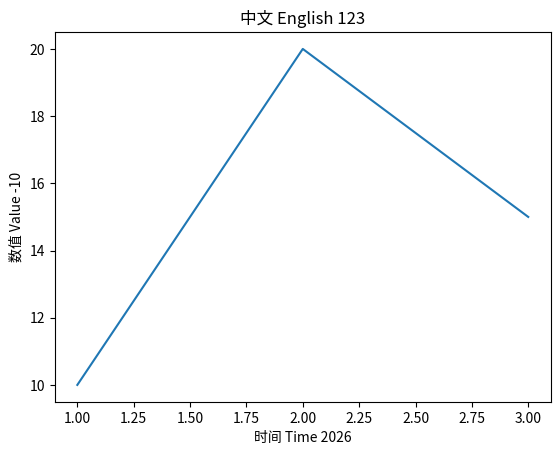

In [1]:
# 🖼️ 配置 matplotlib 中文显示
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

print("🎉 GraphRAG基础概念演示")
print("=" * 50)

🎉 GraphRAG基础概念演示


## 🔍 1. 知识图谱基础概念

知识图谱是由**实体**（节点）和**关系**（边）组成的图结构数据。

In [4]:
# 创建一个简单的糖水店知识图谱
G = nx.Graph()

# 添加实体（节点）
entities = [
    "椰子", "糖浆", "红豆", "西米", "芋圆", "奶茶",
    "椰汁", "椰果", "红豆沙", "糖水", "冷饮", "热饮"
]

for entity in entities:
    G.add_node(entity)

# 添加关系（边）
relationships = [
    ("椰子", "椰汁", "制作"),
    ("椰汁", "奶茶", "原料"),
    ("糖浆", "奶茶", "甜味剂"),
    ("红豆", "红豆沙", "原料"),
    ("红豆沙", "糖水", "成分"),
    ("西米", "糖水", "配料"),
    ("芋圆", "糖水", "配料"),
    ("椰果", "奶茶", "配料"),
    ("奶茶", "冷饮", "类型"),
    ("糖水", "冷饮", "类型"),
    ("糖水", "热饮", "类型")
]

for source, target, relation in relationships:
    G.add_edge(source, target, relation=relation)

print(f"📊 图谱统计：")
print(f"- 实体数量：{G.number_of_nodes()}")
print(f"- 关系数量：{G.number_of_edges()}")
print(f"- 连通性：{nx.is_connected(G)}")

📊 图谱统计：
- 实体数量：12
- 关系数量：11
- 连通性：True


/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 21046 (\N{CJK UNIFIED IDEOGRAPH-5236}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 29980 (\N{CJK UNIFIED IDEOGRAPH-751C}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 21619 (\N{CJK UNIFIED IDEOGRAPH-5473}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 21058 (\N{CJK UNIFIED IDEOGR

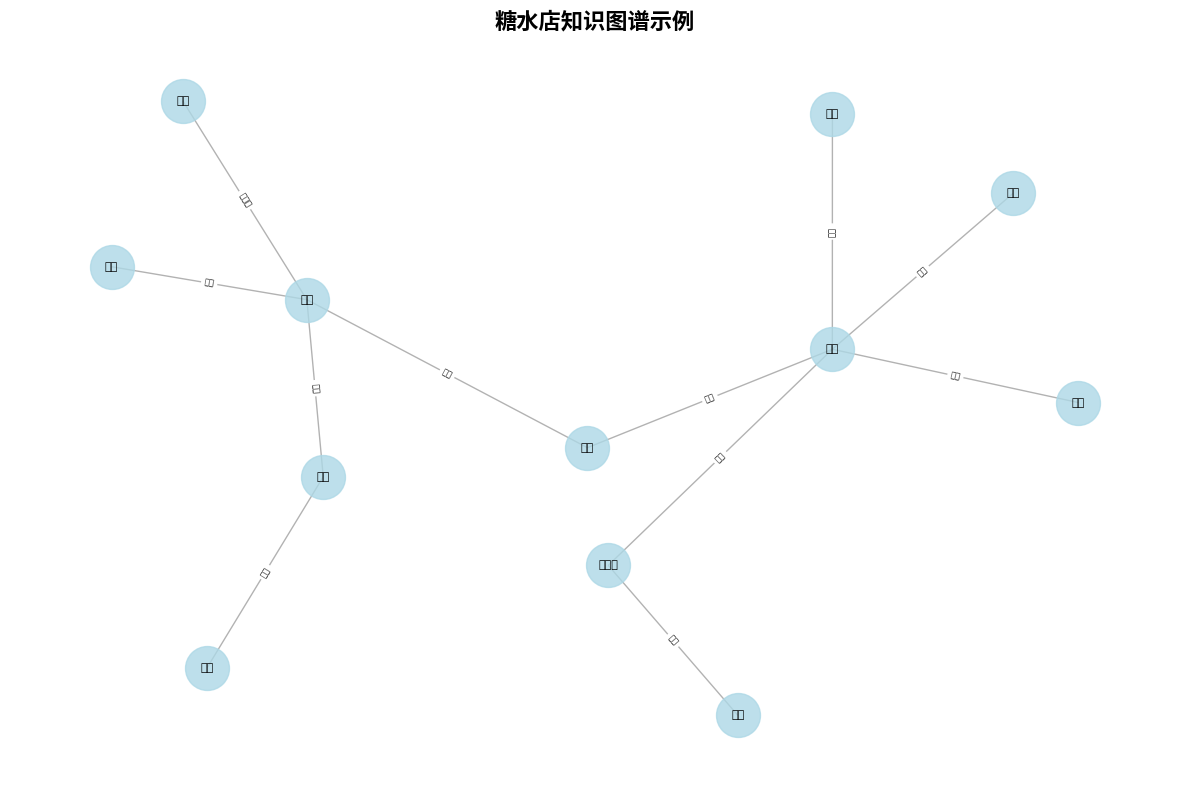

✅ 这是一个小型的知识图谱，展示了糖水店中的实体和关系


In [5]:
# 可视化知识图谱
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1, iterations=50)

# 绘制节点
nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                      node_size=1000, alpha=0.8)

# 绘制边
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 添加标签
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# 添加关系标签（只显示部分避免混乱）
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                            font_size=6)

plt.title("糖水店知识图谱示例", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ 这是一个小型的知识图谱，展示了糖水店中的实体和关系")

## 🧠 2. GraphRAG的工作流程

GraphRAG的核心是将文本转换为图谱，然后利用图谱信息增强检索。

In [6]:
def graph_rag_search(query, graph, top_k=3):
    """
    简化的GraphRAG搜索算法
    """
    print(f"🔍 查询：{query}")
    print("=" * 40)
    # 1. 关键词提取（简化版）
    keywords = ["椰子", "奶茶", "制作", "原料"]  # 简化提取
    print(f"📝 提取的关键词：{keywords}")
    # 2. 相关实体查找
    related_entities = set()
    for keyword in keywords:
        for node in graph.nodes():
            if keyword in str(node):
                related_entities.add(node)

In [8]:
def analyze_recipe_flow(query, graph):
    """
    分析制作流程的 GraphRAG 演示
    """

    print(f"🎯 查询制作流程：{query}")
    print("=" * 50)

    # 查找相关的原材料
    ingredients = [
        node for node in graph.nodes()
        if graph.degree(node) > 2
        and node not in ["冷饮", "热饮"]
    ]

    print(f"📦 可用原材料：{ingredients}")

    # 找出目标产品
    target_products = [
        node for node in graph.nodes()
        if graph.degree(node) > 3
    ]

    print(f"🎁 目标产品：{target_products}")

    # 分析制作路径
    for product in target_products:
        print(f"\n🔬 分析 {product} 的制作路径：")

        # 找到直接原料
        direct_ingredients = [
            neighbor
            for neighbor in graph.neighbors(product)
            if graph.has_edge(product, neighbor)
            and graph.edges[product, neighbor].get("relation") == "原料"
        ]

        if direct_ingredients:
            print(f"直接原料：{direct_ingredients}")

            # 找到原材料的原料
            for ingredient in direct_ingredients:
                sub_ingredients = [
                    sub_neighbor
                    for sub_neighbor in graph.neighbors(ingredient)
                    if graph.has_edge(ingredient, sub_neighbor)
                    and graph.edges[ingredient, sub_neighbor].get("relation") == "原料"
                ]

                if sub_ingredients:
                    print(
                        f"   🌿 {ingredient} 的原料：{sub_ingredients}"
                    )


# 演示制作流程分析
analyze_recipe_flow("奶茶制作流程", G)

print("\n💡 GraphRAG 在业务中的应用价值：")
print("• 自动生成产品推荐")
print("• 发现原料搭配规律")
print("• 分析客户购买偏好")
print("• 优化库存管理")

🎯 查询制作流程：奶茶制作流程
📦 可用原材料：['奶茶', '糖水']
🎁 目标产品：['奶茶', '糖水']

🔬 分析 奶茶 的制作路径：
直接原料：['椰汁']
   🌿 椰汁 的原料：['奶茶']

🔬 分析 糖水 的制作路径：

💡 GraphRAG 在业务中的应用价值：
• 自动生成产品推荐
• 发现原料搭配规律
• 分析客户购买偏好
• 优化库存管理


## 🚀 3. GraphRAG vs 传统RAG对比

In [10]:
import pandas as pd


def compare_rag_methods():
    """
    对比 GraphRAG 和传统 RAG 的优势
    """

    print("🆚 GraphRAG vs 传统RAG 对比")
    print("=" * 60)

    comparison_data = {
        "特性": [
            "语义理解",
            "关系推理",
            "上下文理解",
            "答案质量",
            "查询灵活性",
            "知识更新",
            "计算复杂度",
        ],
        "传统RAG": [
            "文本相似度匹配",
            "有限",
            "段落级",
            "中等",
            "关键词依赖",
            "容易",
            "低",
        ],
        "GraphRAG": [
            "图结构语义",
            "多跳推理",
            "实体级",
            "高",
            "语义理解",
            "需要重新构建",
            "高",
        ],
    }

    df = pd.DataFrame(comparison_data)
    print(df.to_string(index=False))

    print("\n" + "=" * 60)
    print("🎯 适用场景：")

    print("\n📖 传统RAG更适合：")
    print("• 简单事实查询")
    print("• 规则明确的文档检索")
    print("• 快速部署需求")
    print("• 计算资源有限")

    print("\n🕸️ GraphRAG更适合：")
    print("• 复杂关系查询")
    print("• 需要多步推理的任务")
    print("• 知识密集型应用")
    print("• 业务逻辑复杂的场景")


# 执行对比分析
compare_rag_methods()

print("\n🧠 业务场景分析：")

print("\n糖水店适用：")
print("• GraphRAG：分析顾客购买习惯、原料搭配关系")
print("• 传统RAG：查询产品价格、营业时间等基础信息")

print("\n🎯 建议：混合使用，用 GraphRAG 处理复杂推理，传统 RAG 处理简单查询")

🆚 GraphRAG vs 传统RAG 对比
   特性   传统RAG GraphRAG
 语义理解 文本相似度匹配    图结构语义
 关系推理      有限     多跳推理
上下文理解     段落级      实体级
 答案质量      中等        高
查询灵活性   关键词依赖     语义理解
 知识更新      容易   需要重新构建
计算复杂度       低        高

🎯 适用场景：

📖 传统RAG更适合：
• 简单事实查询
• 规则明确的文档检索
• 快速部署需求
• 计算资源有限

🕸️ GraphRAG更适合：
• 复杂关系查询
• 需要多步推理的任务
• 知识密集型应用
• 业务逻辑复杂的场景

🧠 业务场景分析：

糖水店适用：
• GraphRAG：分析顾客购买习惯、原料搭配关系
• 传统RAG：查询产品价格、营业时间等基础信息

🎯 建议：混合使用，用 GraphRAG 处理复杂推理，传统 RAG 处理简单查询


## 🎯 4. GraphRAG实战挑战

In [12]:
def entity_relation_challenge():
    """
    实体关系抽取挑战：从文本中识别实体和关系
    """

    print("🧩 挑战：实体关系抽取")
    print("=" * 40)

    text_data = [
        "椰子是制作椰汁的主要原料。",
        "椰汁可以作为奶茶的基础原料。",
        "红豆可以制作红豆沙，红豆沙是糖水的常见成分。",
        "奶茶和糖水都是冷饮类型。",
    ]

    print("📝 原始文本：")
    for i, text in enumerate(text_data, 1):
        print(f"   {i}. {text}")

    print("\n🎯 任务：识别以下实体和关系")
    print("=" * 40)

    potential_entities = [
        "椰子",
        "椰汁",
        "红豆",
        "红豆沙",
        "糖水",
        "奶茶",
        "冷饮",
    ]

    print(f"🔍 候选实体：{potential_entities}")

    print("\n💡 挑战：")
    print("1. 从每个句子中识别出实体")
    print("2. 识别实体之间的关系类型")
    print("3. 构建三元组（实体1，关系，实体2）")

    print("\n🎓 参考答案：")

    # 标准三元组格式：实体1、关系、实体2
    triples = [
        ("椰子", "是原料", "椰汁"),
        ("椰汁", "是原料", "奶茶"),
        ("红豆", "制作", "红豆沙"),
        ("红豆沙", "是成分", "糖水"),
        ("奶茶", "属于", "冷饮"),
        ("糖水", "属于", "冷饮"),
    ]

    for i, (entity1, relation, entity2) in enumerate(triples, 1):
        print(f"   {i}. ({entity1}, {relation}, {entity2})")

    return triples


# 执行挑战
triples = entity_relation_challenge()

print("\n🚀 GraphRAG 的核心挑战：")
print("• 实体抽取的准确性")
print("• 关系类型的多样性")
print("• 知识图谱的维护成本")
print("• 查询优化的效率")

🧩 挑战：实体关系抽取
📝 原始文本：
   1. 椰子是制作椰汁的主要原料。
   2. 椰汁可以作为奶茶的基础原料。
   3. 红豆可以制作红豆沙，红豆沙是糖水的常见成分。
   4. 奶茶和糖水都是冷饮类型。

🎯 任务：识别以下实体和关系
🔍 候选实体：['椰子', '椰汁', '红豆', '红豆沙', '糖水', '奶茶', '冷饮']

💡 挑战：
1. 从每个句子中识别出实体
2. 识别实体之间的关系类型
3. 构建三元组（实体1，关系，实体2）

🎓 参考答案：
   1. (椰子, 是原料, 椰汁)
   2. (椰汁, 是原料, 奶茶)
   3. (红豆, 制作, 红豆沙)
   4. (红豆沙, 是成分, 糖水)
   5. (奶茶, 属于, 冷饮)
   6. (糖水, 属于, 冷饮)

🚀 GraphRAG 的核心挑战：
• 实体抽取的准确性
• 关系类型的多样性
• 知识图谱的维护成本
• 查询优化的效率


## 📝 课堂练习（5分钟）

🎯 **练习1：实体识别**
从以下句子中识别实体："芋圆和西米都是糖水的常见配料，Q弹口感很好。"

🎯 **练习2：关系推理**
如果A是B的原料，B是C的原料，那么A和C是什么关系？

🎯 **练习3：图谱扩展**
在我们的糖水店图谱中添加新的实体"珍珠"，并建立与奶茶的关系。

💡 **提示**：
- 实体通常是名词，关系通常是动词或介词
- 想象实体就像图的节点，关系就像连接节点的边
- 关系可以是多样的：原料、制作、属于、包含等

## 🎬 推荐视频

📹 **GraphRAG入门教程**（15分钟）
https://www.bilibili.com/video/BV1zb4y1X7Ey

这个视频详细介绍了GraphRAG的基本概念和工作原理，包含实际案例演示。

📹 **知识图谱实战**（25分钟）
https://www.bilibili.com/video/BV1GJ411x7hE

从零开始构建知识图谱的实战教程，非常适合初学者理解图谱构建过程。

## 📖 延伸阅读

🔗 **GraphRAG: Large Language Model Enhanced with Graph Data**
https://arxiv.org/abs/2307.04688

GraphRAG的原始论文，深入介绍了如何用知识图谱增强大语言模型的能力。

🔗 **Microsoft的GraphRAG实现指南**
https://learn.microsoft.com/en-us/azure/cognitive-services/LLM/tutorial-knowledge-graph

Microsoft官方的GraphRAG实现教程，包含代码示例和最佳实践。

## 🔑 今日英文术语

- **Knowledge Graph** [ˈnɒlɪdʒ ɡrɑːf] 知识图谱
- **Entity** [ˈentəti] 实体
- **Relation** [rɪˈleɪʃn] 关系
- **GraphRAG** [ɡræf rag] 图增强检索生成
- **Triple** [ˈtrɪpl] 三元组

## 🔄 往期回顾

**Week 3回顾：** 大模型训练全景
- 预训练：数据、规模与涌现能力
- SFT：监督微调的关键细节
- RLHF：人类反馈强化学习详解
- DPO与其他对齐方法对比
- 训练全流程串联+超参数调优

**Week 2回顾：** Transformer深入理解
- FFN、LayerNorm与残差连接
- Tokenizer与词嵌入
- GPT vs BERT架构对比
- 位置编码：RoPE、ALiBi等
- Transformer推理优化：KV Cache、Flash Attention、GQA

🎯 **进度**：第4周/12 | 当前：RAG与知识增强

📝 **课后测试**（15分钟）

❶ 下列哪个是知识图谱的基本组成部分？
A. 文本和图片
B. 实体和关系
C. 数据和算法
D. 模型和参数

❷ GraphRAG相比传统RAG的主要优势是什么？
A. 查询速度更快
B. 知识准确性更高
C. 支持多步推理
D. 成本更低

❸ 在糖水店知识图谱中，"椰子"和"奶茶"是什么关系？
A. 原料关系
B. 制作关系
C. 产品关系
D. 竞争关系

❹ 下列哪个不是GraphRAG的挑战？
A. 实体抽取难度
B. 关系类型多样性
C. 图谱构建成本
D. 查询优化效率
E. 都不是挑战

❺ 简述GraphRAG的一个实际应用场景。

回复答案我帮你批改 ✅